In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import datetime
import random

## Load the demo data

This loads a CSV of the data from the demo. This is the same kind of file that could be shipped to S3 and then to Quick.

We can also imagine other approaches to analyzing/reporting/visualizing the data.

In [119]:
df = pd.read_csv("pupper_2026-04-29_itslog_summary.csv")
orig = df

## What does it look like?

Let's just look at the dataframe. It looks like a CSV... no surprises there.

In [120]:
df[0:5]

,id,last_run,date,key_id,operation,tags,value,count,hash
0,5992,0,2026-04-29,pup_admin,total_v1_v2_calls_using_since_param_percent,NaN,0,1,83c4326b5a5e999d73d5522002052c30f197c17e
1,6011,0,2026-04-29,pup_admin,total_developer_with_registered_app_count,NaN,0,1,8eed6197fc8b4983c07bc4421897f48e84a6a30a
2,6012,0,2026-04-29,pup_admin,total_developer_with_first_api_call_count,NaN,0,1,ec48c22c16b270448d65699a909eb9bd82d6af67
3,6013,0,2026-04-29,pup_admin,sdk_requests_node_count,NaN,0,1,578289bd5bf001cba16e6ad8e057631fcf413b9e
4,6014,0,2026-04-29,pup_admin,sdk_requests_python_count,NaN,0,1,5530ff30d468366a0de45dab442f17dbbc21ea9a


## Start with app level

What do the app_ level metrics look like for our demo app?

In [121]:
# Pandas provides a rich interface for 
app_level = df[(~df['operation'].str.contains('app_fhir')) & (df['tags'].str.contains('2.')) & (df['value'] != "0") & (df['value'].str.isdigit()) & (df['operation'].str.contains('count'))]

app_level["value"] = pd.to_numeric(app_level["value"])

app_level['operation'] = app_level['operation'].map(lambda s: s[4:19] + "..." + s[-15:])


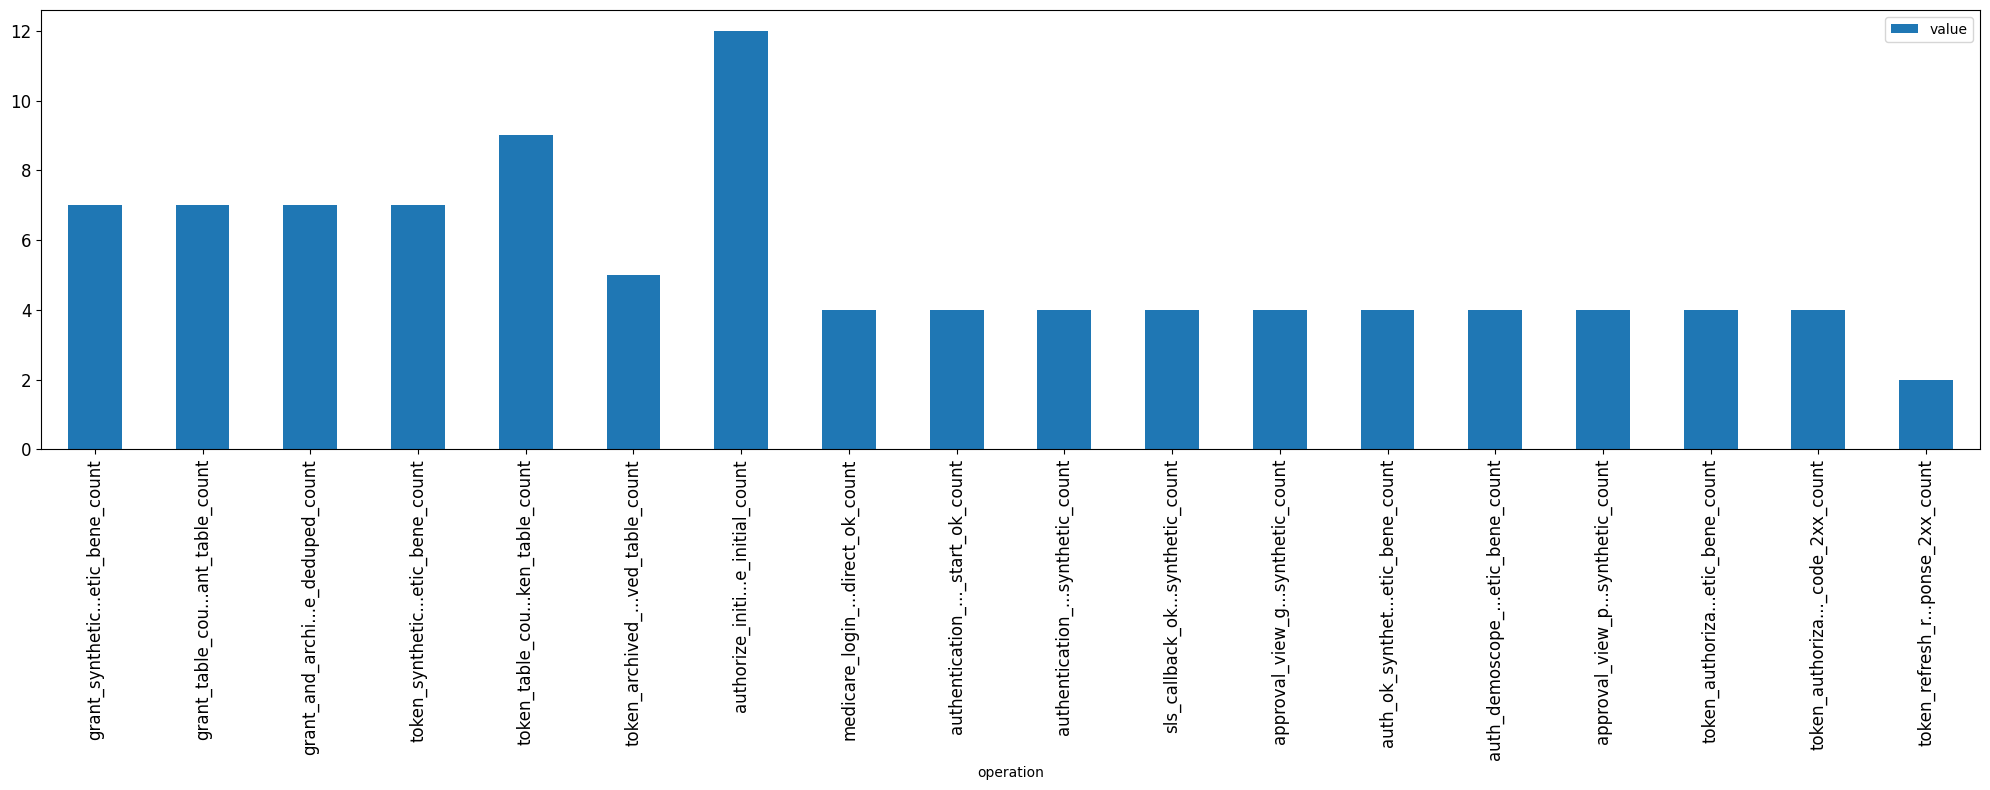

In [122]:
# plt.hist(x=app_level['value'])
plt.rcParams['figure.figsize'] = (20, 8)
app_level.plot.bar(x='operation', y='value', fontsize=12, rot=90)
plt.tight_layout()
plt.show()


## what about the API endpoints?

Put v1, v2, and v3 side-by-side.

In [123]:

v1 = df[df['operation'].str.startswith('fhir_v1')]
v2 = df[df['operation'].str.startswith('fhir_v2')]
v3 = df[df['operation'].str.startswith('fhir_v3')]
v1['value'] = pd.to_numeric(v1['value'])
v2['value'] = pd.to_numeric(v2['value'])
v3['value'] = pd.to_numeric(v3['value'])

# labels = app_level['operation'] = app_level['operation'].map(lambda s: s[4:19] + "..." + s[-15:])
labels = v1['operation'].map(lambda s: s[8:])

#print(len(v1['value'].tolist()), len(v2['value'].tolist()), len(v3['value'].tolist()))
#print(v1['value'].tolist(), v2['value'].tolist(), v3['value'].tolist())

side_by_each = pd.DataFrame({
    "v1": v1['value'].tolist(),
    "v2": v2['value'].tolist(),
    "v3": v3['value'].tolist()[0:13]
}, index=labels)



## Top-line?

What does the data look like for 30 days in summary?

<Axes: xlabel='operation'>

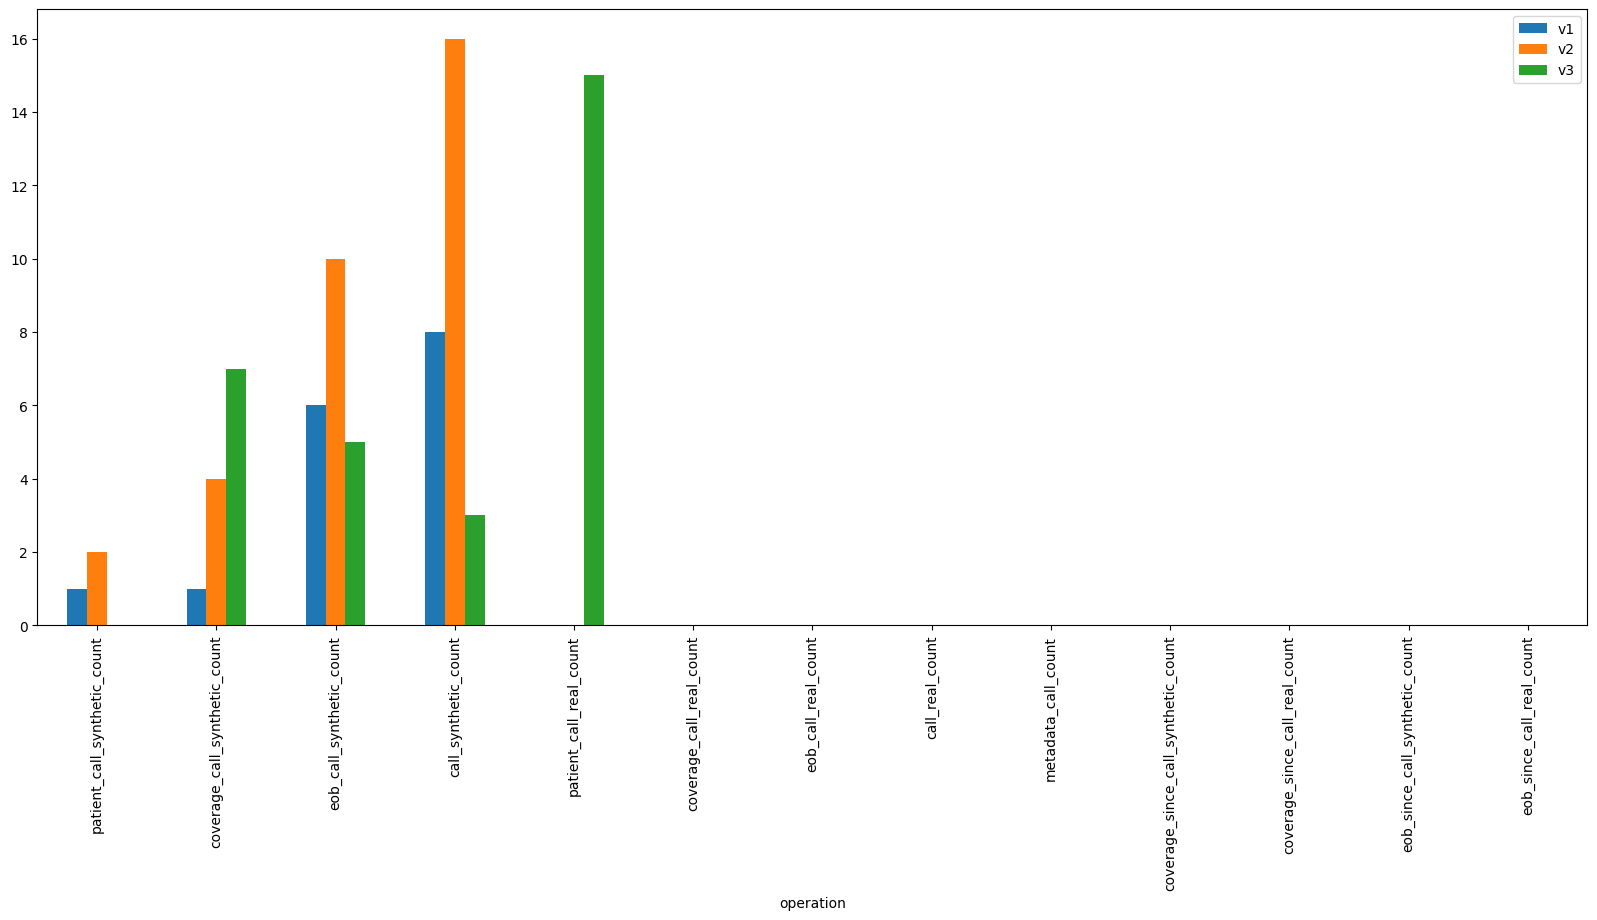

In [124]:
side_by_each.plot(kind='bar')

## Now, fake a month

Let's expand this out to a month of (fake) data.

In [125]:
# id,last_run,date,key_id,operation,tags,value,count,hash
df = orig
for i in range(30):
    nextdf = df[df['date'] == '2026-04-29']
    next_day = datetime.datetime.strptime('2026-04-29', "%Y-%m-%d") + datetime.timedelta(days=i+1)
    nextdf['date'] = nextdf['date'].map(lambda d: f"{next_day:%Y-%m-%d}")
    # Randomize values for all totals in the new frame
    nextdf['value'] = nextdf['value'].map(lambda v: random.randint(3,30))
    df = pd.concat([df, nextdf])


In [127]:

v1 = df[df['operation'].str.startswith('fhir_v1')]
v2 = df[df['operation'].str.startswith('fhir_v2')]
v3 = df[df['operation'].str.startswith('fhir_v3')]
v1['value'] = pd.to_numeric(v1['value'])
v2['value'] = pd.to_numeric(v2['value'])
v3['value'] = pd.to_numeric(v3['value'])

# labels = app_level['operation'] = app_level['operation'].map(lambda s: s[4:19] + "..." + s[-15:])
labels = v1['operation'].map(lambda s: s[8:])

#print(len(v1['value'].tolist()), len(v2['value'].tolist()), len(v3['value'].tolist()))
#print(v1['value'].tolist(), v2['value'].tolist(), v3['value'].tolist())

side_by_each = pd.DataFrame({
    "v1": v1['value'].tolist(),
    "v2": v2['value'].tolist(),
    "v3": v3['value'].tolist()[0:403]
}, index=labels)



<Axes: xlabel='operation'>

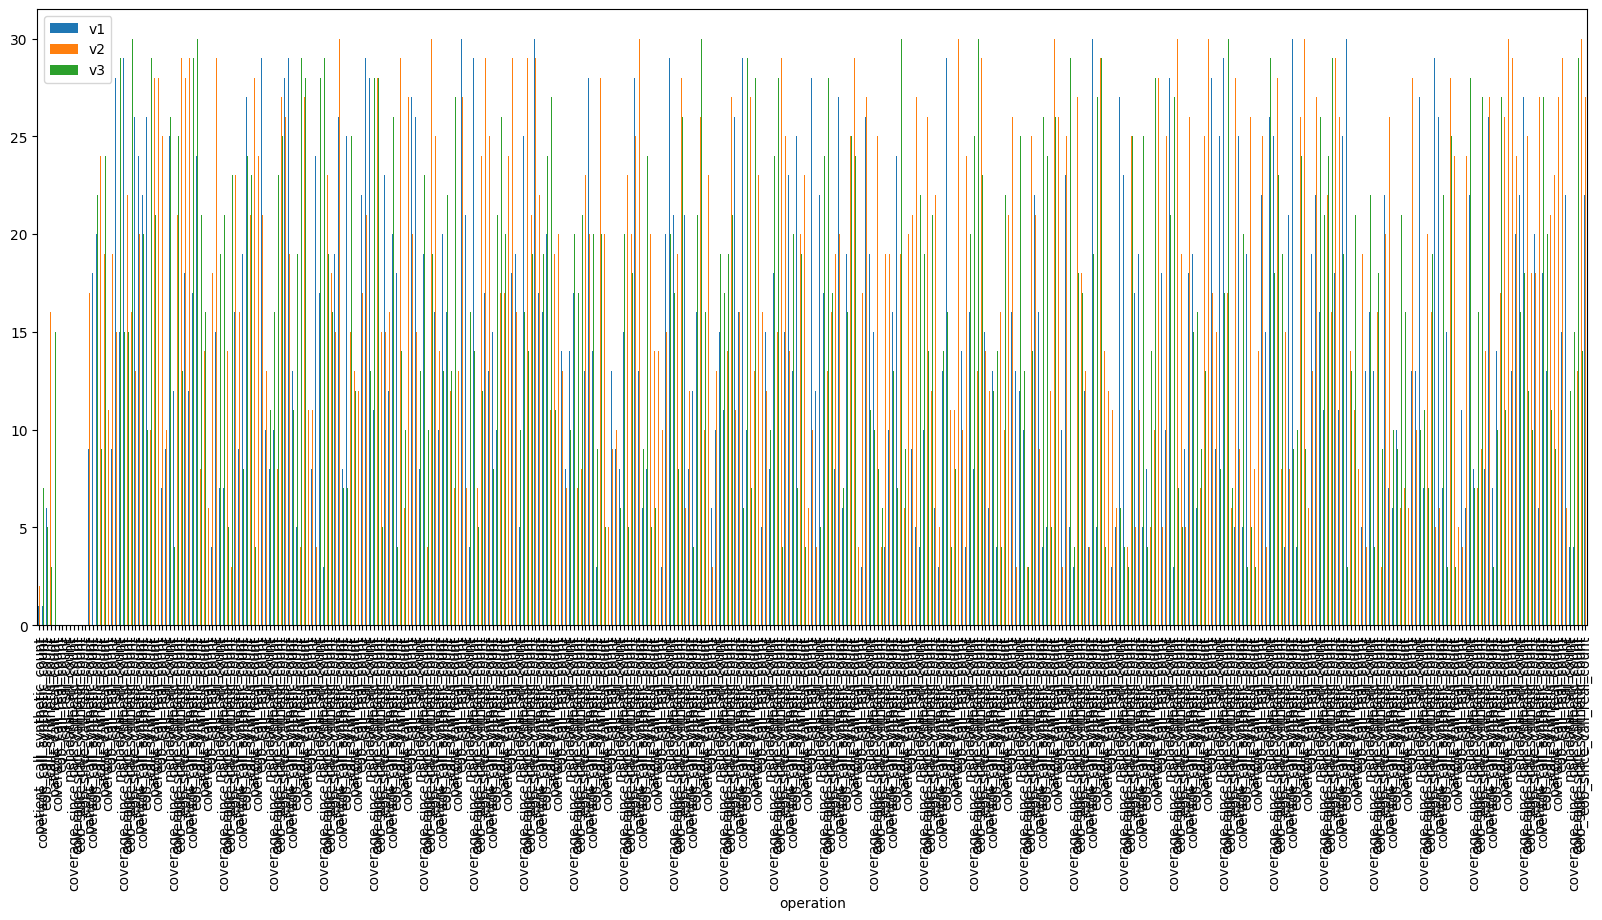

In [128]:
side_by_each.plot(kind='bar')

## that looks horrible

What if we consolidate those counts? :D

['patient_call_synthetic_count', 'coverage_call_synthetic_count', 'eob_call_synthetic_count', 'call_synthetic_count', 'patient_call_real_count', 'coverage_call_real_count', 'eob_call_real_count', 'call_real_count', 'metadata_call_count', 'coverage_since_call_synthetic_count', 'coverage_since_call_real_count', 'eob_since_call_synthetic_count', 'eob_since_call_real_count']


<Axes: >

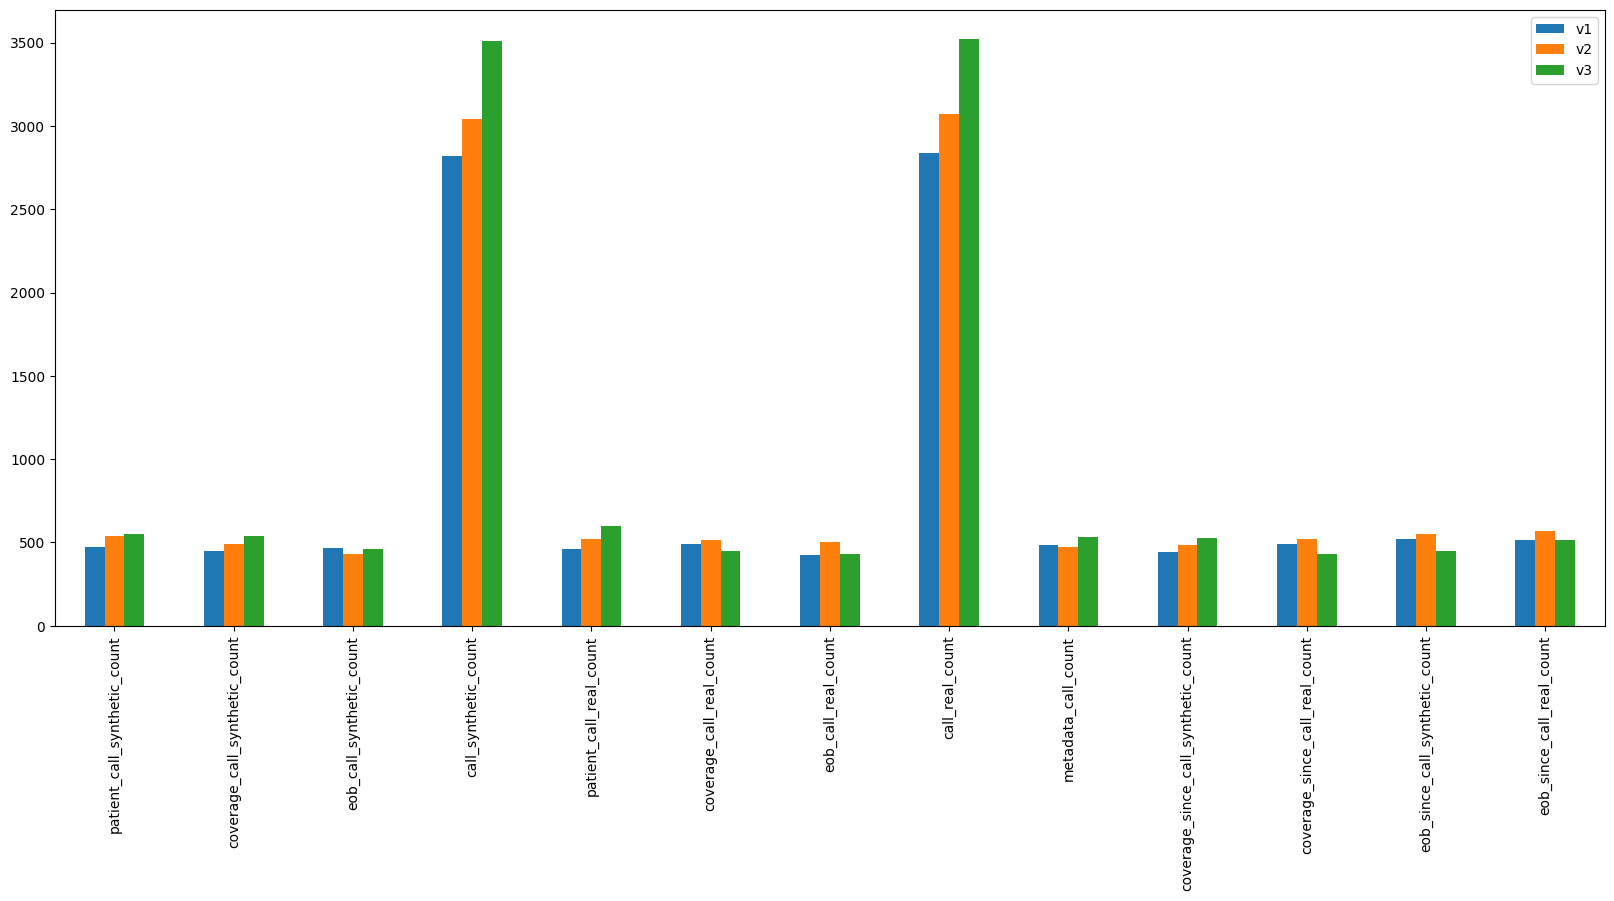

In [139]:
# Get the unique keys
keys = list(map(lambda s: s[8:], df[df['operation'].str.startswith('fhir_v1')]['operation'].unique().tolist()))
# Strip the version info
print(keys)

# Now, sum for each unique key, by version
frames = {}
for ver in ['v1', 'v2', 'v3']:
    frames[ver] = pd.DataFrame(columns=['operation', 'value'])
    for key in keys:
        newv = sum(map(lambda s: int(s), df[df['operation'].str.startswith(f'fhir_{ver}') & df['operation'].str.contains(key)]['value'].tolist()))
        frames[ver].loc[len(frames[ver])] = {'operation': f'fhir_{ver}_{key}', 'value': newv}

consolidated = pd.DataFrame({
    "v1": frames['v1']['value'].tolist(),
    "v2": frames['v2']['value'].tolist(),
    "v3": frames['v3']['value'].tolist()
}, index=keys)

consolidated.plot(kind='bar')